In [7]:
from typing import TypedDict , List , Annotated
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage

from langgraph.graph import StateGraph , START,END
from langgraph.types import Send

In [8]:
load_dotenv()

True

In [2]:
class Task(BaseModel):
    id:int
    title:str
    brief:str=Field(...,description="What to cover") 

In [3]:
class Plan(BaseModel):
    blog_title:str
    tasks:list[Task]

In [5]:
class State(TypedDict):
    topic:str
    plan :Plan
    sections:Annotated[list[str],operator.add]
    final :str

In [9]:
llm=ChatGroq(model='openai/gpt-oss-120b')

In [10]:
def orchestrator(state:State)->dict:
    plan=llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 sections on the following topic")
                    ),
                    HumanMessage(content=f"Topic:{state['topic']}")
                ]
        )
    return {'plan':plan}

In [11]:
def fanout(state:State):
    return [Send('worker',{'task':task,'topic':state['topic'],"plan":state['plan']})
            for task in state['plan'].tasks]

In [12]:
def worker(payload:dict)->dict:
    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']

    blog_title=plan.blog_title

    section_md=llm.invoke(
        [
            SystemMessage(content='Write one clean markdown section'),
            HumanMessage(
                content=(
                        f"Blog:{blog_title}\n"
                        f"Topic:{topic}\n\n"
                        f"Section:{task.title}\n"
                        f"Brief:{task.brief}\n\n"
                        "Return the section content in markdown file only ")
                        )
        ]
    ).content.strip()

    return {'sections':[section_md]}

In [13]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [14]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

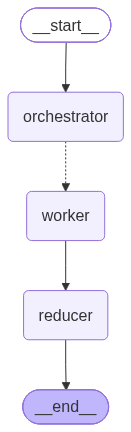

In [15]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [16]:
out=app.invoke({"topic":"Write a blog on Cross Attention","sections":[]})

In [18]:
print(out)

{'topic': 'Write a blog on Cross Attention', 'plan': Plan(blog_title='Understanding Cross-Attention: Theory, Applications, and Implementation', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the concept of attention in deep learning, differentiate between self‑attention and cross‑attention, and set the stage for why cross‑attention matters.'), Task(id=2, title='Mathematical Foundations of Cross‑Attention', brief='Derive the cross‑attention equations, describe query, key, and value matrices, and illustrate how the dot‑product attention works across two separate sequences.'), Task(id=3, title='Cross‑Attention in Transformer Architectures', brief='Show where cross‑attention appears in encoder‑decoder models, multimodal transformers (e.g., Vision‑Language), and recent variants like T5, BART, and CLIP.'), Task(id=4, title='Practical Use‑Cases and Benefits', brief='Discuss real‑world scenarios such as machine translation, image captioning, text‑to‑image genera